In [246]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [227]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [279]:
x = pd.read_excel("/content/HR analytics.xlsx")
x

,Name,Gender,Department,Pay,Loc,Rating
0,Ches Bonnell,Male,Sales,"$88,050",Bellevue,Very Good
1,Garwin Peasegood,Female,Engineering,"$68,220",Bellevue,Good
2,Sidoney Yitzhok,Female,NaN,"$118,440",Wellington,Not Rated
3,Saunders Blumson,Male,Legal,"$56,370",Los Angeles,Very Good
4,Gardy Grigorey,Female,Support,"$107,090",Los Angeles,Poor
...,...,...,...,...,...,...
1010,Shaylyn Ransbury,Female,Support,"$100,370",Wellington,Average
1011,Christoph Stretton,Female,Business Development,"$90,240",Wellington,Poor
1012,Jordain Cyster,Female,Engineering,"$75,870",Los Angeles,Average
1013,Malory Biles,Female,Training,"$58,740",Los Angeles,Not Rated


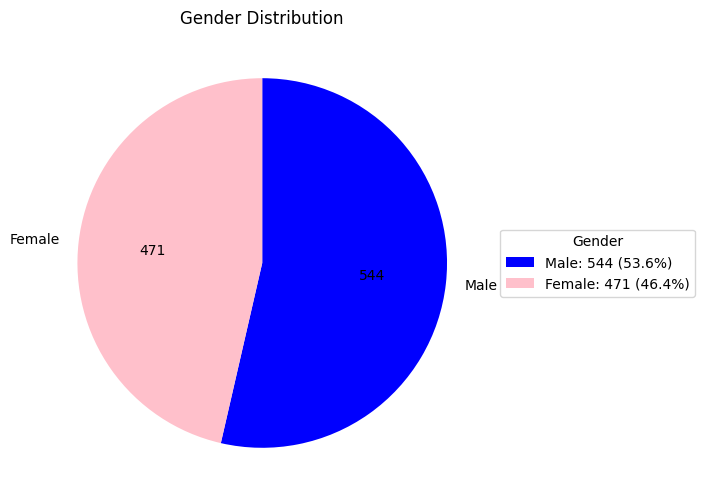

In [229]:
# 1. Number of Males and Females in the Organization.

gender_counts = x['Gender'].value_counts()
gender_percentages = x['Gender'].value_counts(normalize=True) * 100

df = pd.DataFrame({'count': gender_counts, 'percentage': gender_percentages})

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue' if gender == 'Male' else 'pink' for gender in df.index]
ax.pie(df['count'], labels=df.index, startangle=90, counterclock=False, autopct=lambda p: '{:.0f}'.format(p * sum(df['count']) / 100), colors=colors)

plt.title('Gender Distribution')

labels = [f'{gender}: {count} ({percentage:.1f}%)' for gender, count, percentage in zip(df.index, df['count'], df['percentage'])]
ax.legend(labels, title="Gender", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()

<Axes: xlabel='Department', ylabel='Gender'>

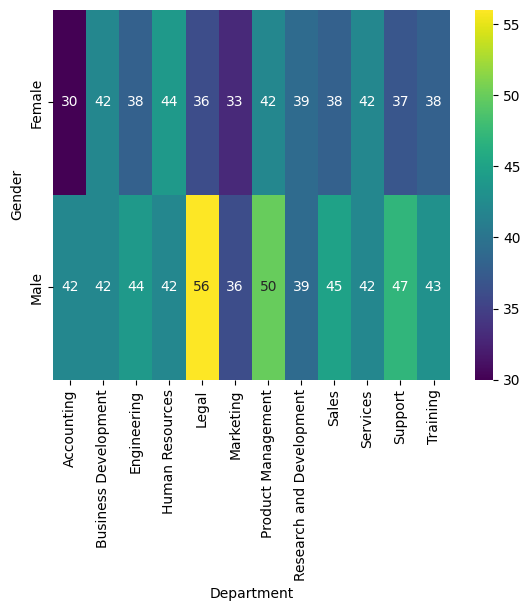

In [230]:
# 2a. Number of males and females in each department.

crosstab = pd.crosstab(x['Gender'], x['Department'])

sns.heatmap(crosstab, annot=True, cmap='viridis')

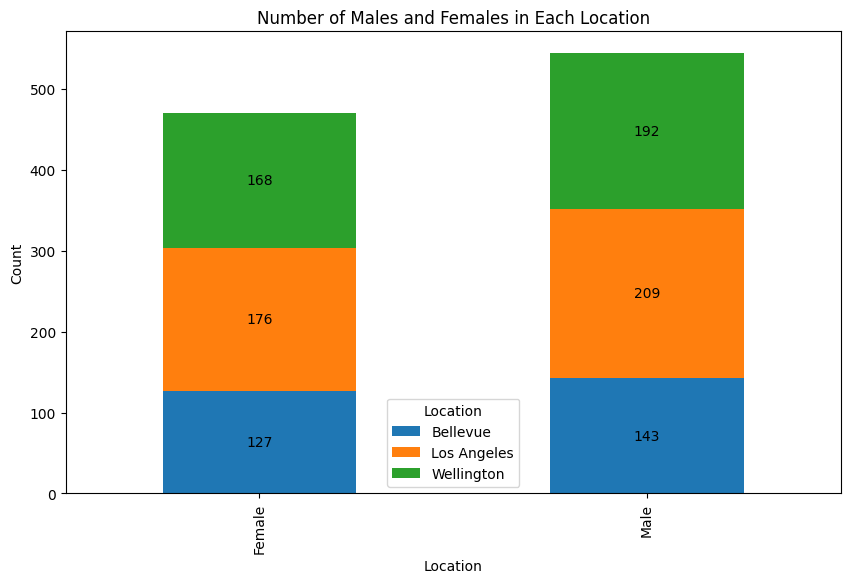

In [280]:
# 2b. Stacked bar chart showing number of males and females working in respective locations.

crosstab = pd.crosstab(x['Gender'], x['Loc'])

fig, ax = plt.subplots()

fig.set_size_inches(10, 6)

crosstab.plot.bar(stacked=True, ax=ax)

ax.set_title('Number of Males and Females in Each Location')
ax.set_xlabel('Location')
ax.set_ylabel('Count')
ax.legend(title='Location')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x+width/2,
            y+height/2,
            '{:.0f}'.format(height),
            horizontalalignment='center',
            verticalalignment='center')

plt.show()

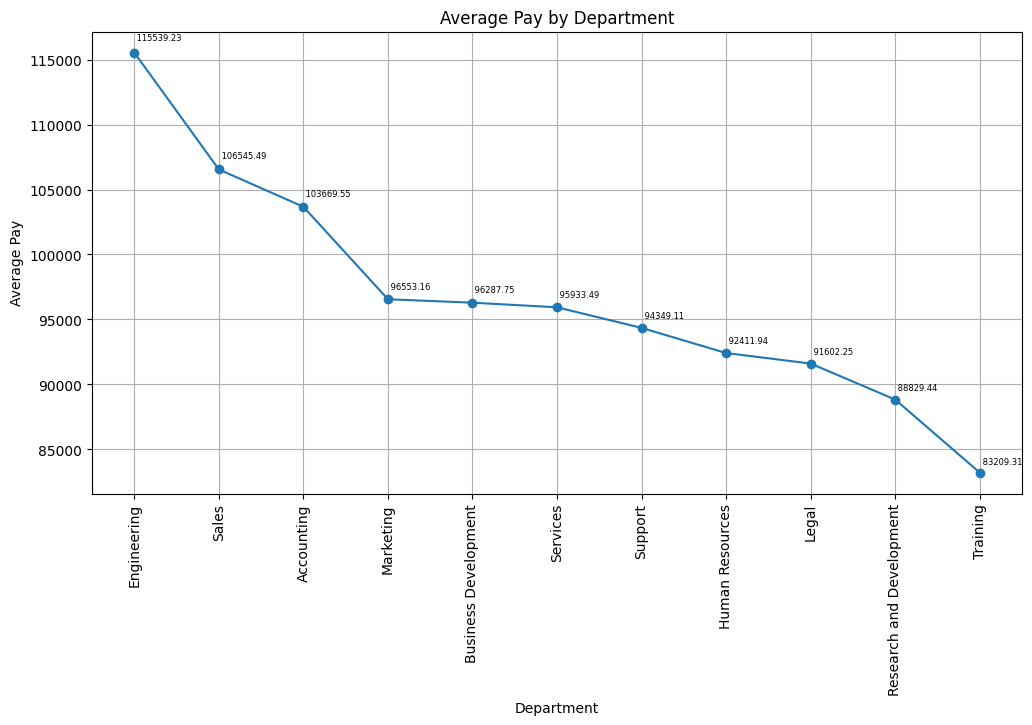

In [243]:
# 3. Highest Average Pay in terms of Department.

avg_pay = df.groupby('Department')['Pay'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.plot(avg_pay.index, avg_pay.values, marker='o')

for i, v in enumerate(avg_pay.values):
    plt.text(i, v + 0.01 * v, f' {v:.2f}', va='center', ha='left', fontsize=6)

plt.xticks(rotation=90)
plt.xlabel('Department')
plt.ylabel('Average Pay')
plt.title('Average Pay by Department')
plt.grid(True)

plt.show()

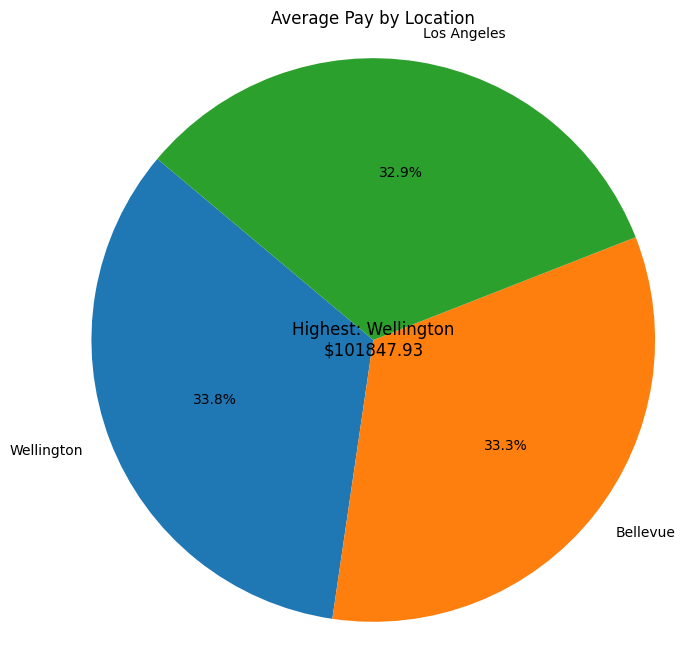

In [282]:
# 4. Highest Average Pay in terms of location.

np.random.seed(0)
num_employees = 500
locations = ['Bellevue', 'Los Angeles', 'Wellington']
data = {
    'Loc': np.random.choice(locations, num_employees),
    'Pay': np.random.randint(0, 200000, num_employees)
}
df = pd.DataFrame(data)

avg_pay = df.groupby('Loc')['Pay'].mean().sort_values(ascending=False)

highest_loc = avg_pay.idxmax()
highest_avg_pay = avg_pay.max()

plt.figure(figsize=(8, 8))
plt.pie(avg_pay, labels=avg_pay.index, autopct='%1.1f%%', startangle=140)
plt.title('Average Pay by Location')

plt.annotate(f'Highest: {highest_loc}\n${highest_avg_pay:.2f}',
             xy=(0.5, 0.5), xycoords='axes fraction',
             fontsize=12, ha='center', va='center')

plt.axis('equal')
plt.show()

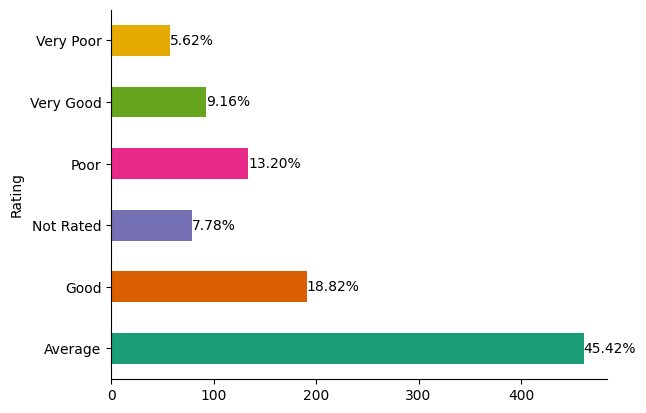

In [258]:
# 5. Rating in percentage form

rating_counts = x.groupby('Rating').size()

total = sum(rating_counts)
rating_percentages = [(count/total)*100 for count in rating_counts]

bars = rating_counts.plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))

plt.gca().spines[['top', 'right']].set_visible(False)

for i in range(len(rating_counts)):
    plt.text(rating_counts[i], i, f'{rating_percentages[i]:.2f}%', va = 'center')

plt.show()

In [254]:
# 6. Computation of gender pay gap for each department. Interpreted.

gender_pay_avg = df.groupby(['Department', 'Gender']).mean().reset_index()

gender_pay_pivot = gender_pay_avg.pivot(index='Department', columns='Gender', values='Pay')

gender_pay_pivot['GenderPayGap(%)'] = ((gender_pay_pivot['Male'] - gender_pay_pivot['Female']) / gender_pay_pivot['Male']) * 100

gender_pay_pivot_sorted = gender_pay_pivot.sort_values(by='GenderPayGap(%)', ascending=False)

for department in gender_pay_pivot_sorted.index:
    male_pay = gender_pay_pivot_sorted.loc[department, 'Male']
    female_pay = gender_pay_pivot_sorted.loc[department, 'Female']
    pay_gap = gender_pay_pivot_sorted.loc[department, 'GenderPayGap(%)']

    print(f"In the {department} department:")
    if pay_gap > 0:
        print(f"Men earn {pay_gap:.2f}% more than women.")
    elif pay_gap < 0:
        print(f"Women earn {-pay_gap:.2f}% more than men.")
    else:
        print("There is no gender pay gap.")


In the Legal department:
Men earn 21.11% more than women.
In the Business Development department:
Men earn 17.33% more than women.
In the Accounting department:
Men earn 16.11% more than women.
In the Marketing department:
Men earn 14.64% more than women.
In the Engineering department:
Men earn 10.64% more than women.
In the Research and Development department:
Men earn 9.79% more than women.
In the Support department:
Men earn 6.38% more than women.
In the Training department:
Men earn 3.05% more than women.
In the Sales department:
Women earn 2.80% more than men.
In the Human Resources department:
Women earn 19.15% more than men.
In the Services department:
Women earn 26.56% more than men.


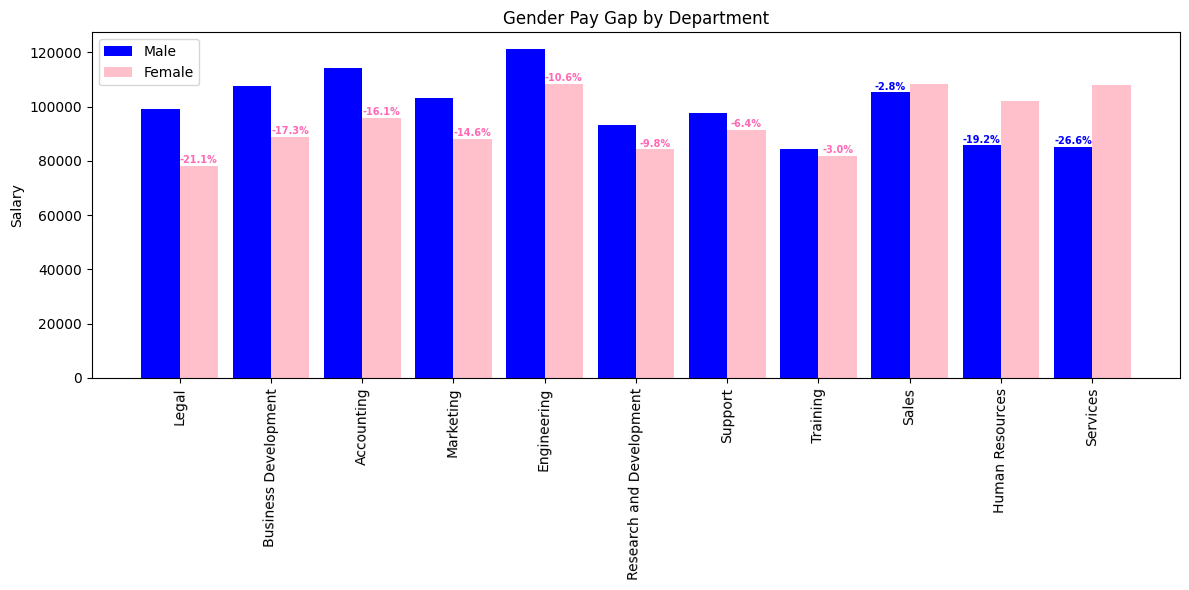

In [239]:
np.random.seed(0)
num_employees = 500
departments = [
    'Accounting', 'Business Development', 'Engineering', 'Human Resources', 'Legal',
    'Marketing', 'Research and Development', 'Sales', 'Services', 'Support', 'Training'
]

data = {
    'Department': np.random.choice(departments, num_employees),
    'Gender': np.random.choice(['Male', 'Female'], num_employees),
    'Pay': np.random.randint(0, 200000, num_employees)
}

df = pd.DataFrame(data)

gender_pay_avg = df.groupby(['Department', 'Gender']).mean().reset_index()

gender_pay_pivot = gender_pay_avg.pivot(index='Department', columns='Gender', values='Pay')

gender_pay_pivot['GenderPayGap(%)'] = ((gender_pay_pivot['Male'] - gender_pay_pivot['Female']) / gender_pay_pivot['Male']) * 100

gender_pay_pivot_sorted = gender_pay_pivot.sort_values(by='GenderPayGap(%)', ascending=False)

labels = gender_pay_pivot_sorted.index
male_means = gender_pay_pivot_sorted['Male']
female_means = gender_pay_pivot_sorted['Female']
pay_gap = gender_pay_pivot_sorted['GenderPayGap(%)']

x = np.arange(len(labels))
width = 0.42

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, male_means, width, color='blue', label='Male')
rects2 = ax.bar(x + width/2, female_means, width, color='pink', label='Female')

ax.set_ylabel('Salary')
ax.set_title('Gender Pay Gap by Department')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=89)
ax.legend()

for i, v in enumerate(pay_gap):
    if v < 0:
        ax.text(i - width/2, male_means[i] + 1000, f'-{abs(v):.1f}%', color='blue', fontweight='bold', ha='center', fontsize=7)
    else:
        ax.text(i + width/2, female_means[i] + 1000, f'-{v:.1f}%', color='hotpink', fontweight='bold', ha='center', fontsize=7)

fig.tight_layout()

plt.show()


In [238]:
# 7. Computation of gender pay gap for each location. Interpreted.
gender_pay_avg = df.groupby(['Loc', 'Gender']).mean().reset_index()

gender_pay_pivot = gender_pay_avg.pivot(index='Loc', columns='Gender', values='Pay')

gender_pay_pivot['GenderPayGap(%)'] = ((gender_pay_pivot['Male'] - gender_pay_pivot['Female']) / gender_pay_pivot['Male']) * 100

gender_pay_pivot_sorted = gender_pay_pivot.sort_values(by='GenderPayGap(%)', ascending=False)

for loc in gender_pay_pivot_sorted.index:
    male_pay = gender_pay_pivot_sorted.loc[loc, 'Male']
    female_pay = gender_pay_pivot_sorted.loc[loc, 'Female']
    pay_gap = gender_pay_pivot_sorted.loc[loc, 'GenderPayGap(%)']

    print(f"In the {loc} location:")
    if pay_gap > 0:
        print(f"Men earn {pay_gap:.2f}% more than women.")
    elif pay_gap < 0:
        print(f"Women earn {-pay_gap:.2f}% more than men.")
    else:
        print("There is no gender pay gap.")


In the Los Angeles location:
Women earn 2.44% more than men.
In the Bellevue location:
Women earn 3.23% more than men.
In the Wellington location:
Women earn 8.89% more than men.


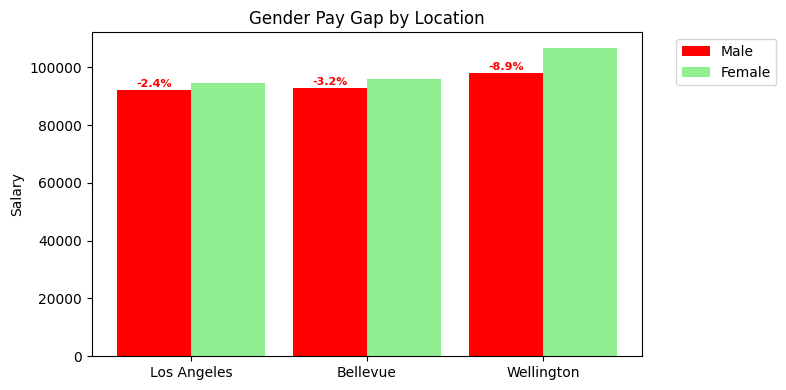

In [237]:
np.random.seed(0)
num_employees = 500
locations = ['Bellevue', 'Los Angeles', 'Wellington']

data = {
    'Loc': np.random.choice(locations, num_employees),
    'Gender': np.random.choice(['Male', 'Female'], num_employees),
    'Pay': np.random.randint(0, 200000, num_employees)
}

df = pd.DataFrame(data)

gender_pay_avg = df.groupby(['Loc', 'Gender']).mean().reset_index()

gender_pay_pivot = gender_pay_avg.pivot(index='Loc', columns='Gender', values='Pay')

gender_pay_pivot['GenderPayGap(%)'] = ((gender_pay_pivot['Male'] - gender_pay_pivot['Female']) / gender_pay_pivot['Male']) * 100

gender_pay_pivot_sorted = gender_pay_pivot.sort_values(by='GenderPayGap(%)', ascending=False)

labels = gender_pay_pivot_sorted.index
male_means = gender_pay_pivot_sorted['Male']
female_means = gender_pay_pivot_sorted['Female']
pay_gap = gender_pay_pivot_sorted['GenderPayGap(%)']

x = np.arange(len(labels))
width = 0.42

fig, ax = plt.subplots(figsize=(8, 4))  # Adjust the size here
rects1 = ax.bar(x - width/2, male_means, width, color='red', label='Male')
rects2 = ax.bar(x + width/2, female_means, width, color='lightgreen', label='Female')

ax.set_ylabel('Salary')
ax.set_title('Gender Pay Gap by Location')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Position the legend

for i, v in enumerate(pay_gap):
    if v < 0:
        ax.text(i - width/2, male_means[i] + 1000, f'-{abs(v):.1f}%', color='red', fontweight='bold', ha='center', fontsize=8)
    else:
        ax.text(i + width/2, female_means[i] + 1000, f'{v:.1f}%', color='lightgreen', fontweight='bold', ha='center', fontsize=8)

fig.tight_layout()

plt.show()
